# Questions  

1. What is the total number of patients ?

2. How is the patient population distributed by gender?

3. Patient’s Age-group by total visit.

4. Which diseases are most commonly diagnosed among the patients?

5. Are certain diseases more prevalent in one gender compared to the other?

6. Calculate the duration of each patient stay and create a group to show numbers of patients in each group.

7. For any records with a recorded course of death, analyze patterns to identify risk factors.

8. What are the percentage of the following patients: Deceased, under-treatment and Recovered patients?

9. What are the peak days of the week on a monthly bases for admissions and discharges?

10. What is the total number of patients admitted per week, month and year? Add a filter to filter the month by Year.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Load in Data from csv 
health_data = pd.read_csv('Health_dataset.csv')

#Display the firs rows
print(health_data.head())

  Patient ID  Gender       Disease         Treatment               Hospital  \
0  PAT-00001    Male  Tuberculosis          Dialysis  City General Hospital   
1  PAT-00002  Female       Malaria          Dialysis  City General Hospital   
2  PAT-00003  Female       Malaria           Surgery  City General Hospital   
3  PAT-00004    Male        Asthma          Dialysis  City General Hospital   
4  PAT-00005  Female      Diabetes  Physical Therapy  City General Hospital   

  Admission Date Discharge Date Treatment Status Cause of Death Date of Birth  
0     2022-12-19     2023-01-16        Recovered            NaN    1973-06-05  
1     2023-03-29     2023-04-21        Recovered            NaN    1998-11-21  
2     2022-09-16     2022-10-15        Recovered            NaN    1942-02-14  
3     2022-02-07     2022-02-11        Recovered            NaN    1943-01-17  
4     2022-10-25     2022-10-30        Recovered            NaN    1979-07-28  


In [2]:
#Count the number of patients
total_records = health_data.shape[0]

# What is the total Number of Patients?
print('Total Patients',total_records)

Total Patients 8000


In [3]:
# How is the patients population distributed by gender?

gender_count = health_data['Gender'].value_counts()
print('Gender Distrubuion:')
print(gender_count)

Gender Distrubuion:
Gender
Male      5206
Female    2794
Name: count, dtype: int64


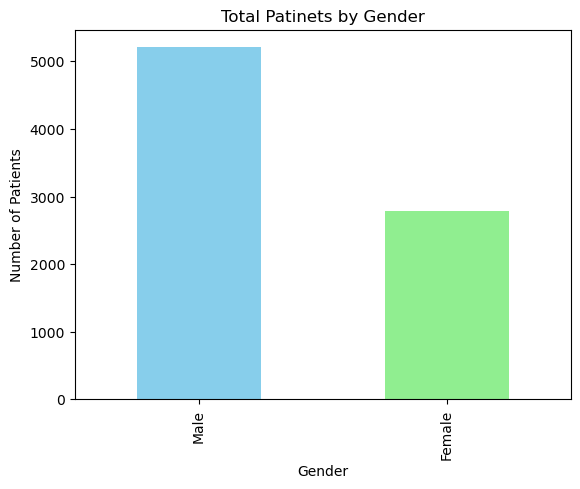

In [4]:
# Visualize gender distribution :
gender_count.plot(kind='bar', color =['skyblue','lightgreen'])

plt.title('Total Patinets by Gender')
plt.ylabel('Number of Patients')
plt.show()

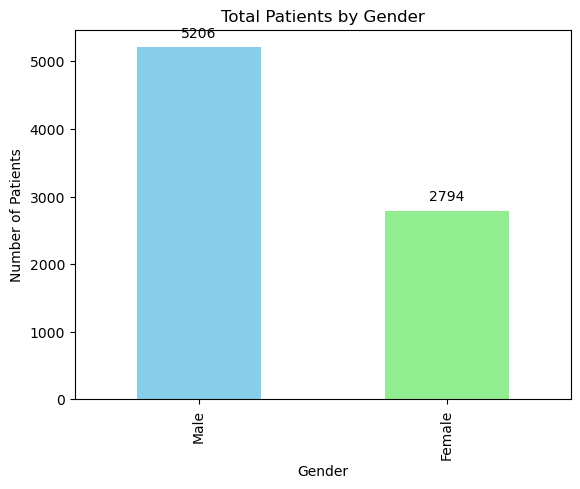

In [5]:
# Visualize gender distribution :
# Adding Data Label 
ax= gender_count.plot(kind='bar', color =['skyblue','lightgreen'])

plt.title('Total Patients by Gender')
plt.ylabel('Number of Patients')


#label Part:
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        int(height),
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext =(0,5),
        textcoords ='offset points',
        ha='center',
        va='bottom'
    )
    
plt.show()

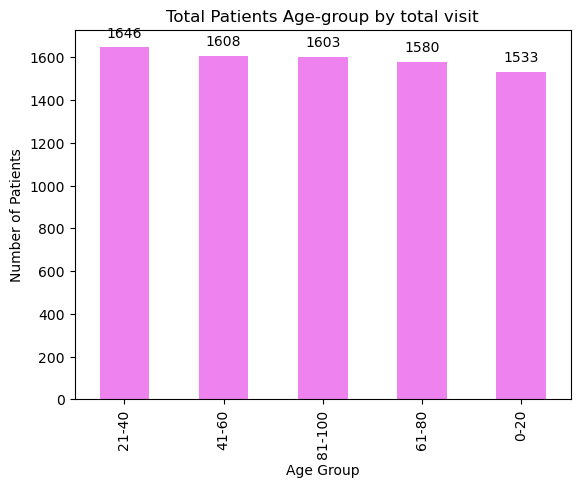

Age Group
21-40     1646
41-60     1608
81-100    1603
61-80     1580
0-20      1533
Name: count, dtype: int64


In [6]:
#Patient Age-Group by total vist

#Convert the Admissoin Date and Date of Birth to Proper Date Format
health_data['Admission Date'] = pd.to_datetime(health_data['Admission Date'])
health_data['Date of Birth'] = pd.to_datetime(health_data['Date of Birth'])

#Calculate the patient age as the time of Admission in Year
health_data['Age'] = (health_data['Admission Date'] - health_data['Date of Birth']).dt.days / 365.25
health_data['Age'] = health_data['Age'].astype(int)

# Define age bins
bins = [0,20,40,60,80,100]

labels = ['0-20','21-40','41-60','61-80','81-100']


# Create an age group using the bins var diffined 
health_data['Age Group'] = pd.cut(health_data['Age'], bins=bins, labels=labels, right=False)

# Count the Number of Patients in each age group
age_count = health_data['Age Group'].value_counts()

#Visualize he Age Group
ax= age_count.plot(kind='bar', color='Violet')

plt.title('Total Patients Age-group by total visit')
plt.ylabel('Number of Patients')

#label Part:
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        int(height),
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext =(0,5),
        textcoords ='offset points',
        ha='center',
        va='bottom'
    )
    
plt.show()
print(age_count)


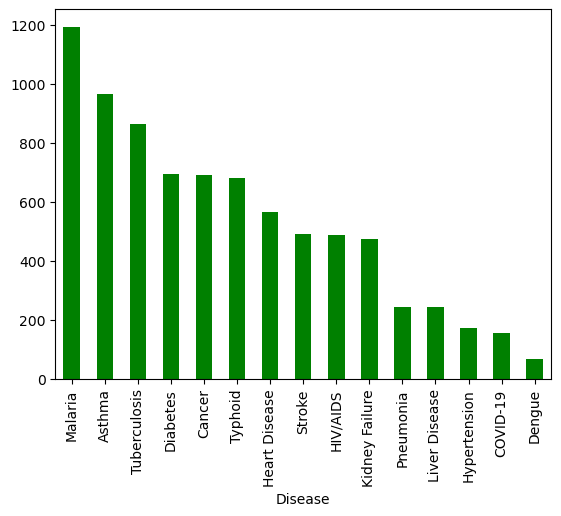

In [7]:
# Which diseases are most commonly diagonised among the patients?

diseases_counts = health_data['Disease'].value_counts()
ax= diseases_counts.plot(kind='bar', color='Green')


In [8]:
disease_count = health_data['Disease'].value_counts().nlargest(3) # Get the top 3 Diseases
disease_count

Disease
Malaria         1193
Asthma           966
Tuberculosis     864
Name: count, dtype: int64

In [9]:
disease_count = health_data['Disease'].value_counts().nlargest(3) # Get the top 3 Diseases
total_top3 = disease_count.sum()

format_value ='{:,}'.format(total_top3)
print('Total Count of the 3 most common Diseases:', format_value)

Total Count of the 3 most common Diseases: 3,023


In [10]:

dynamictop = 7
disease_count = health_data['Disease'].value_counts().nlargest(dynamictop) # Get the top 3 Diseases
total_top = disease_count.sum()
format_value ='{:,}'.format(total_top)
description = f'Total Count of the {dynamictop} most common Diseases:'
print(description,format_value)

Total Count of the 7 most common Diseases: 5,655


In [11]:
disease_counttop3 = health_data['Disease'].value_counts().nlargest(3) # Get the top 3 Diseases
total_diseases_count= health_data['Disease'].value_counts().sum()

#Calculate the top 3 Percentage 

percentage = (disease_counttop3/total_diseases_count)*100
percentage

Disease
Malaria         14.9125
Asthma          12.0750
Tuberculosis    10.8000
Name: count, dtype: float64

In [12]:
disease_counttop3 = health_data['Disease'].value_counts().nlargest(3) # Get the top 3 Diseases
total_diseases_count= health_data['Disease'].value_counts().sum()

#Calculate the top 3 Percentage 

percentage = (disease_counttop3/total_diseases_count)*100


roundpercentage = percentage.round(0).astype(int)
roundpercentage

Disease
Malaria         15
Asthma          12
Tuberculosis    11
Name: count, dtype: int32

In [13]:
disease_counttop3 = health_data['Disease'].value_counts().nlargest(3) # Get the top 3 Diseases
total_diseases_count= health_data['Disease'].value_counts().sum()

#Calculate the top 3 Percentage 

percentage = (disease_counttop3/total_diseases_count)*100


roundpercentage = percentage.round(0).astype(int)


for disease, pct in roundpercentage.items():
    print(f'{disease}:{pct}%')

Malaria:15%
Asthma:12%
Tuberculosis:11%


In [14]:
disease_counttop3 = health_data['Disease'].value_counts().nlargest(3) # Get the top 3 Diseases
total_diseasestop3count = disease_counttop3.sum()
#Calculate the top 3 Percentage 


pcttop3 = (disease_counttop3/total_diseasestop3count)*100

roundpct = pcttop3.round(0).astype(int)

for disease, pct in roundpct.items():
    print(f'{disease}:{pct}%')

Malaria:39%
Asthma:32%
Tuberculosis:29%


In [15]:
# Any Certain diseases more prevalent in one gender compared to the other?

gender_disease = pd.crosstab(health_data['Disease'],health_data['Gender'])
print('Diseases that are common among genders')
gender_disease

Diseases that are common among genders


Gender,Female,Male
Disease,,
Asthma,320,646
COVID-19,53,104
Cancer,239,452
Dengue,27,42
Diabetes,256,438
HIV/AIDS,155,333
Heart Disease,206,361
Hypertension,65,108
Kidney Failure,182,293


### Calculate the duration of each patient stay and create a group to show numbers of patients in each group.

In [16]:
# converted date in proper date data type
health_data['Admission Date'] = pd.to_datetime(health_data['Admission Date'])
health_data['Discharge Date'] = pd.to_datetime(health_data['Discharge Date'])

health_data['Stay Duration'] = (health_data['Discharge Date'] - health_data['Admission Date']).dt.days
print(health_data[['Admission Date','Discharge Date','Stay Duration']].head(10))

  Admission Date Discharge Date  Stay Duration
0     2022-12-19     2023-01-16             28
1     2023-03-29     2023-04-21             23
2     2022-09-16     2022-10-15             29
3     2022-02-07     2022-02-11              4
4     2022-10-25     2022-10-30              5
5     2022-02-07     2022-02-15              8
6     2022-06-07     2022-06-30             23
7     2022-06-26     2022-06-27              1
8     2023-07-21     2023-08-07             17
9     2023-12-25     2024-01-05             11


### Group Stay Duration

In [17]:
bins =[-1,0,3,7,14, float('inf')]
labels = ['Same Day', '1-3 Days','4-7 Days','8-14 Days','Above 21 Days']
health_data['Stay Bucket']= pd.cut(health_data['Stay Duration'],bins=bins,labels=labels, right= True)
print(health_data['Stay Bucket'])

0       Above 21 Days
1       Above 21 Days
2       Above 21 Days
3            4-7 Days
4            4-7 Days
            ...      
7995         4-7 Days
7996    Above 21 Days
7997        8-14 Days
7998    Above 21 Days
7999    Above 21 Days
Name: Stay Bucket, Length: 8000, dtype: category
Categories (5, object): ['Same Day' < '1-3 Days' < '4-7 Days' < '8-14 Days' < 'Above 21 Days']


### Numbers of Patient on Each Group

In [18]:
total_group_Patient = health_data['Stay Bucket'].value_counts()
print(total_group_Patient)

Stay Bucket
Above 21 Days    4269
8-14 Days        1837
4-7 Days         1087
1-3 Days          807
Same Day            0
Name: count, dtype: int64


### Create chart to Visualize it

Text(0, 0.5, 'Total Patients')

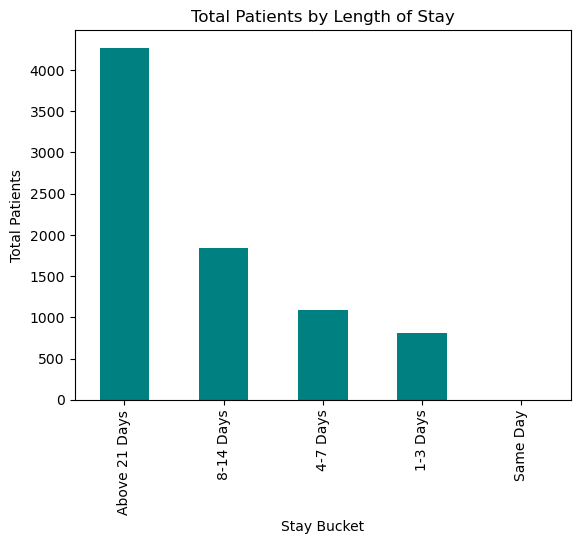

In [19]:
total_group_Patient.plot(kind='bar',color=['Teal'])
plt.title('Total Patients by Length of Stay')
plt.ylabel('Total Patients')

## For any Records with Recorded course of Death, Analyze Pattern to identify risk Factor

In [20]:
# Filter Records where the cause of death is not empty
death_cause = health_data.dropna(subset='Cause of Death')

count_cause = death_cause['Cause of Death'].value_counts()

print('Most Common Cause of Death')
print(count_cause)

Most Common Cause of Death
Cause of Death
Multiple Organ Failure    114
Respiratory Failure       109
Cardiac Arrest            102
Septic Shock               94
Name: count, dtype: int64


### Visualize the finding

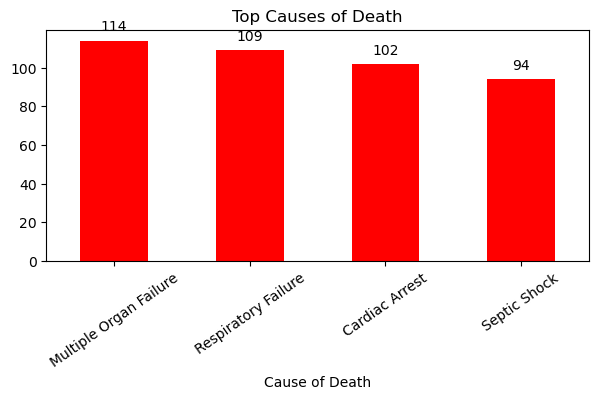

In [21]:
plt.figure (figsize = (7,3))
ax = count_cause.plot(kind='bar',color='red')
plt.xticks(rotation = 35)
plt.title('Top Causes of Death')
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        int(height),
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext =(0,5),
        textcoords ='offset points',
        ha='center',
        va='bottom'
    )
    
plt.show()

## What are the Percentage of the following Patients: Deceased, under-treatment and Recovered Patients ?

In [22]:
# Total Patients
total_patients = health_data.shape[0]
total_patients

8000

In [23]:
# Total Death Patients
total_death = (health_data['Treatment Status'].str.lower() =='deceased').sum()
total_death

419

In [24]:
# Percentage of deceased
death_rate = (total_death/total_patients)*100 if total_patients>0 else 0
death_rate

5.2375

In [25]:
print(f'Total Patients',total_patients)
print(f'Total Casualties', total_death)
print(f'Casuality Rate',death_rate)

Total Patients 8000
Total Casualties 419
Casuality Rate 5.2375


## Recovered Patients

In [26]:
# Total Recovered Patients
total_recovered = (health_data['Treatment Status'].str.lower() =='recovered').sum()
print('Total Recovered Patients')
print(total_recovered)

# Percentage of Recovered Patietns 
recovered_rate = (total_recovered/total_patients)*100 if total_patients>0 else 0
print('Percentage of Recovered Patietns ')
print(recovered_rate)

Total Recovered Patients
6819
Percentage of Recovered Patietns 
85.2375


## Under Treatment Patients

In [27]:
# ALl patients under Treatment
under_treatment = 100 - (recovered_rate+death_rate)
under_treatment

9.525000000000006

## Show this as a Dought Chart 

In [28]:
print(f'Total Recovery Rate:',recovered_rate)
print(f'Casuality Rate:',death_rate)
print(f'Under Treatment Rate', under_treatment)

Total Recovery Rate: 85.2375
Casuality Rate: 5.2375
Under Treatment Rate 9.525000000000006


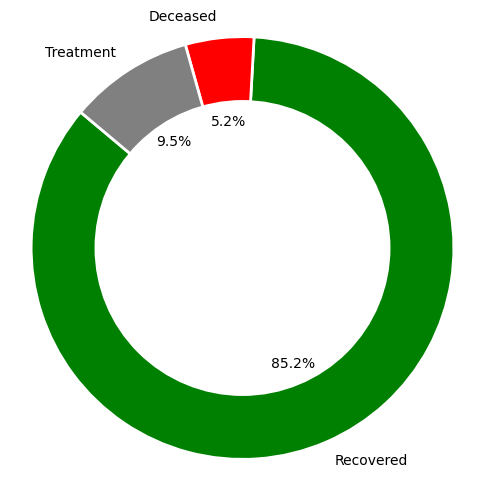

In [29]:
labels=['Recovered','Deceased','Treatment']
sizes = [recovered_rate, death_rate, under_treatment]
colors=['green','red','grey']

plt. figure(figsize=(6,6))
plt.pie(sizes, labels= labels, autopct='%1.1f%%'
,colors = colors, startangle=140, wedgeprops={'edgecolor':'white','linewidth':2})
plt.gca().add_artist(plt.Circle((0,0),0.70, fc='white'))

plt.axis('equal')
plt.show()

## What are the Peak Days of the Week on a monthly bases for Admission and Discharges ?

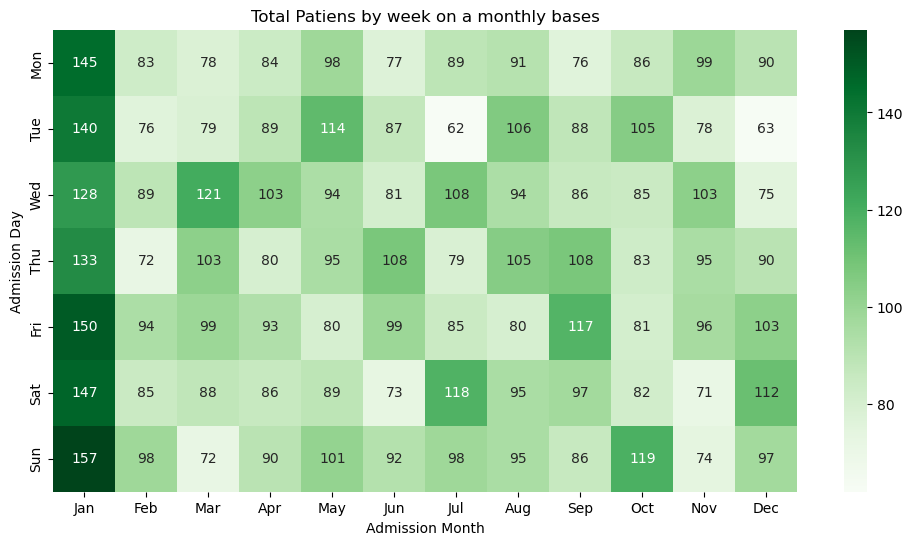

In [30]:
# Convert Admission date to proper date format

health_data['Admission Date'] = pd.to_datetime(health_data['Admission Date'],errors = 'coerce')


# Extract the Short Day and Month Name
health_data['Admission Month'] = health_data['Admission Date'].dt.strftime('%b')
health_data['Admission Day'] = health_data['Admission Date'].dt.strftime('%a')


# Define proper order for month and abbreviated days
month_order = [
    'Jan','Feb','Mar','Apr','May','Jun',
    'Jul','Aug','Sep','Oct','Nov','Dec'
]

day_order= ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']


# Create a PivotTable
admission_heatmap = health_data.pivot_table(
    index = 'Admission Day',
    columns = 'Admission Month',
    aggfunc = 'size',
    fill_value = 0
)

# Correct re order of heathmap data 

admission_heatmap_sorted = admission_heatmap.reindex(index = day_order, columns = month_order)

# Plot the Heatmap
plt.figure(figsize =(12,6))
sns.heatmap(admission_heatmap_sorted,annot = True, fmt = 'd',cmap='Greens' )
plt.title('Total Patiens by week on a monthly bases')
plt.show()

## What is the Total Number of Patients Admitted per Week, Month and Year? Add a Filter to Filter the Month by Year

In [31]:
# Create a new Column
health_data['Admission Day'] = health_data['Admission Date'].dt.strftime('%a')

# Group data by the Day Name and Count Admission
admission_by_day = health_data.groupby('Admission Day').size()

# Sort the name of Day
day_order= ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
admission_by_day = admission_by_day.reindex(day_order,fill_value=0)
admission_by_day

Admission Day
Mon    1096
Tue    1087
Wed    1167
Thu    1151
Fri    1177
Sat    1143
Sun    1179
dtype: int64

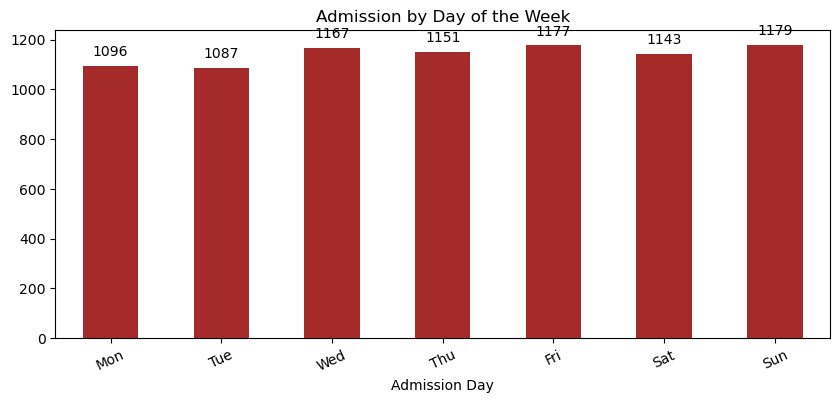

In [32]:
# Create a Visual
ax = admission_by_day.plot(kind='bar',color ='Brown',figsize=(10,4))
plt.title('Admission by Day of the Week')
plt.xticks(rotation=25)
for bar in ax.patches:
    height = bar.get_height()
    ax.annotate(
        int(height),
        xy=(bar.get_x() + bar.get_width()/2, height),
        xytext =(0,5),
        textcoords ='offset points',
        ha='center',
        va='bottom'
    )
    
plt.show()

In [33]:
# Top 3 Days with High Admission
top_3_admission_day = health_data['Admission Day'].value_counts().nlargest(3)
top_3_admission_day

Admission Day
Sun    1179
Fri    1177
Wed    1167
Name: count, dtype: int64

In [34]:
# Bottom 3 Days with High Admission
bottom_3_admission_day = health_data['Admission Day'].value_counts().nsmallest(3)
bottom_3_admission_day

Admission Day
Tue    1087
Mon    1096
Sat    1143
Name: count, dtype: int64

## Total Admission by Month Filtered by Year

In [35]:
# Filter using the year of Admission

selected_year = 2022
health_data_year = health_data[health_data['Admission Date'].dt.year== selected_year].copy()

# Adding the month Column
health_data_year['Admission Month']=health_data_year['Admission Date'].dt.month

# Month Name
health_data_year ['Month Name'] = health_data_year['Admission Date'].dt.month_name()

# Total Admissionon on a Monthly basis
monthly_admission =(
    health_data_year
    .groupby(['Admission Month', 'Month Name'])
    .size()
    .reset_index(name ='Total Patients')
    .sort_values('Admission Month')
                
)
print(f'Total Patients Admitted in the Year {selected_year}')
monthly_admission

Total Patients Admitted in the Year 2022


,Admission Month,Month Name,Total Patients
0,1,January,351
1,2,February,291
2,3,March,313
3,4,April,327
4,5,May,349
5,6,June,315
6,7,July,327
7,8,August,329
8,9,September,311
9,10,October,311


## Create a line Chart to  visualize it

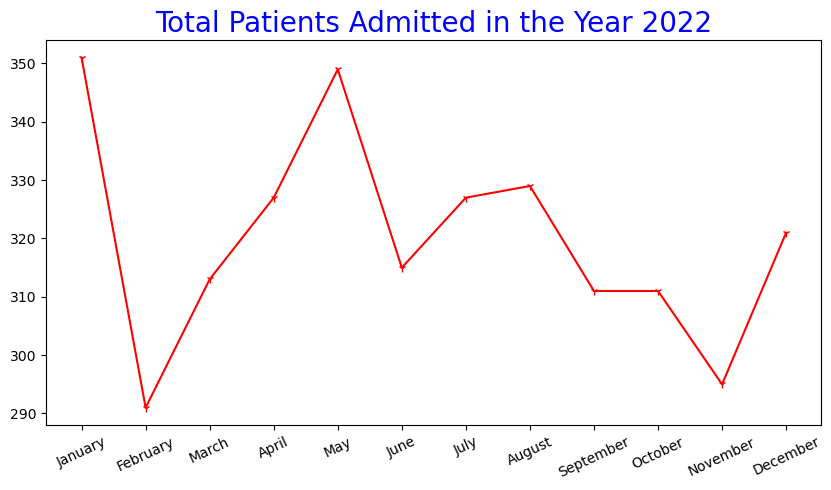

In [36]:
# Setting the Figure Size
plt.figure(figsize=(10,5))

# Ploting the Data
plt.plot(monthly_admission ['Month Name'], monthly_admission ['Total Patients'],
        marker = '1', linestyle = '-',color = 'red'
        )
plt.title(f'Total Patients Admitted in the Year {selected_year}',
         fontsize = 20, color = 'Blue'
         )
plt.xticks(rotation =25)
plt.show()